In [7]:
import gc

gc.collect()

1233

# elevator-rmnd

Use the simulated dataset generated by `dataset.py` to train
regression models, in order to predict the remaining useful life (RUL)
of lifts.

**This approach uses classical ML techniques.**

In [8]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib as jl
import seaborn as sns
import os

sns.set_theme(context="notebook", style="ticks")

MODEL_DIR = os.path.join(os.getcwd(), "models")

## preprocessing
* Import the simulated dataset
* ~~Convert lift ids to integers~~ [already handled by `dataset.py`]
* ~~Compute instantaneous time derivatives of each sensor metric~~ [already handled by `dataset.py`] 
* ~~Compute RUL in h~~ [already handled by `dataset.py`]
* Split data into training/testing sets
* Scale data with a `Scaler`

In [9]:
df_full = pd.read_pickle("liftdata_v3.pkl")
df_full.head(10)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done,...,arm_door_ratio,floor_door_ratio,temp_x_rope,cumulative_rope_degradation,cumulative_bearing_heat,ARM_DIST_mm_per_hr,DOOR_DIST_mm_per_hr,FLOOR_DIST_mm_per_hr,ROPE_MFL_mV_per_hr,BEARING_TEMP_C_per_hr
0,2023-01-01 00:00:00,1,Otis Gen2,15000,0.480,1.996,0.028,10.045,33.693,0,...,0.240481,0.014028,338.446185,10.045,33.693,0.0000,0.0000,0.0000,0.0000,0.0000
1,2023-01-01 12:00:00,1,Otis Gen2,15012,0.527,2.065,0.144,9.681,36.860,0,...,0.255206,0.069734,356.841660,19.726,70.553,0.0039,0.0057,0.0097,-0.0303,0.2639
2,2023-01-02 00:00:00,1,Otis Gen2,15024,0.501,2.244,0.197,9.351,35.014,0,...,0.223262,0.087790,327.415914,29.077,105.567,-0.0022,0.0149,0.0044,-0.0275,-0.1538
3,2023-01-02 12:00:00,1,Otis Gen2,15036,0.498,2.031,0.208,9.458,34.025,0,...,0.245199,0.102413,321.808450,38.535,139.592,-0.0003,-0.0178,0.0009,0.0089,-0.0824
4,2023-01-03 00:00:00,1,Otis Gen2,15048,0.533,2.217,0.471,10.870,36.996,0,...,0.240415,0.212449,402.146520,49.405,176.588,0.0029,0.0155,0.0219,0.1177,0.2476
5,2023-01-03 12:00:00,1,Otis Gen2,15060,0.530,2.276,0.485,9.975,36.493,0,...,0.232865,0.213093,364.017675,59.380,213.081,-0.0003,0.0049,0.0012,-0.0746,-0.0419
6,2023-01-04 00:00:00,1,Otis Gen2,15072,0.536,2.389,0.085,9.975,36.464,0,...,0.224362,0.035580,363.728400,69.355,249.545,0.0005,0.0094,-0.0333,0.0000,-0.0024
7,2023-01-04 12:00:00,1,Otis Gen2,15084,0.556,2.166,0.446,10.252,36.737,0,...,0.256694,0.205909,376.627724,79.607,286.282,0.0017,-0.0186,0.0301,0.0231,0.0228
8,2023-01-05 00:00:00,1,Otis Gen2,15096,0.585,2.249,0.132,10.477,37.251,0,...,0.260115,0.058693,390.278727,90.084,323.533,0.0024,0.0069,-0.0262,0.0187,0.0428
9,2023-01-05 12:00:00,1,Otis Gen2,15108,0.573,2.364,0.834,11.572,36.114,0,...,0.242386,0.352792,417.911208,101.656,359.647,-0.0010,0.0096,0.0585,0.0912,-0.0948


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

Since there exist rows that have `np.inf` as their predicted RUL, extract those rows for experimentation later on.
Retain the remaining roles (with valid RULs) for training and testing.

In [18]:
df_full.dropna(inplace=True)  # Drop any records with missing values

df_experimental = df_full[
    df_full["RUL_hrs"] == np.inf
]  # Filter out records with no further maintenance
df_useful = df_full[
    df_full["RUL_hrs"] != np.inf
]  # Retain the remaining records for training/testing

# Check to see the experimental/useful split was done correctly
assert all(
    df_experimental["RUL_hrs"] == np.inf
), "All records in experimental set should have RUL_hrs == np.inf"
assert all(
    df_useful["RUL_hrs"] != np.inf
), "All records in useful set should have valid RUL_hrs"

df_useful.head(40)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done,...,arm_door_ratio,floor_door_ratio,temp_x_rope,cumulative_rope_degradation,cumulative_bearing_heat,ARM_DIST_mm_per_hr,DOOR_DIST_mm_per_hr,FLOOR_DIST_mm_per_hr,ROPE_MFL_mV_per_hr,BEARING_TEMP_C_per_hr
142,2023-03-13 00:00:00,1,Otis Gen2,16704,1.507,7.714,10.128,17.462,75.193,1,...,0.195359,1.312937,1313.020166,2059.949,7925.487,0.0027,0.0016,0.0021,-0.1110,-0.0293
143,2023-03-13 12:00:00,1,Otis Gen2,16716,0.492,2.087,0.079,9.907,33.291,0,...,0.235745,0.037853,329.813937,2069.856,7958.778,-0.0846,-0.4689,-0.8374,-0.6296,-3.4918
144,2023-03-14 00:00:00,1,Otis Gen2,16728,0.483,2.071,0.005,10.555,34.098,0,...,0.233221,0.002414,359.904390,2080.411,7992.876,-0.0008,-0.0013,-0.0062,0.0540,0.0673
145,2023-03-14 12:00:00,1,Otis Gen2,16740,0.540,2.087,0.322,10.248,35.311,0,...,0.258744,0.154288,361.867128,2090.659,8028.187,0.0048,0.0013,0.0264,-0.0256,0.1011
146,2023-03-15 00:00:00,1,Otis Gen2,16752,0.528,2.177,0.241,10.670,34.296,0,...,0.242535,0.110703,365.938320,2101.329,8062.483,-0.0010,0.0075,-0.0068,0.0352,-0.0846
147,2023-03-15 12:00:00,1,Otis Gen2,16764,0.528,2.187,0.183,10.131,35.045,0,...,0.241427,0.083676,355.040895,2111.460,8097.528,0.0000,0.0008,-0.0048,-0.0449,0.0624
148,2023-03-16 00:00:00,1,Otis Gen2,16776,0.504,2.295,0.832,11.048,36.034,0,...,0.219608,0.362527,398.103632,2122.508,8133.562,-0.0020,0.0090,0.0541,0.0764,0.0824
149,2023-03-16 12:00:00,1,Otis Gen2,16788,0.514,2.314,0.669,10.738,36.379,0,...,0.222126,0.289110,390.637702,2133.246,8169.941,0.0008,0.0016,-0.0136,-0.0258,0.0287
150,2023-03-17 00:00:00,1,Otis Gen2,16800,0.502,2.294,0.672,11.244,34.894,0,...,0.218832,0.292938,392.348136,2144.490,8204.835,-0.0010,-0.0017,0.0003,0.0422,-0.1237
151,2023-03-17 12:00:00,1,Otis Gen2,16812,0.538,2.218,0.837,10.575,35.182,0,...,0.242561,0.377367,372.049650,2155.065,8240.017,0.0030,-0.0063,0.0137,-0.0558,0.0240


Then perform a 85/15 train/test split on the remaining useful data.

In [32]:
print(X.columns)

Index(['lift_id', 'lift_age_hours', 'ARM_DIST_mm', 'DOOR_DIST_mm',
       'FLOOR_DIST_mm', 'ROPE_MFL_mV', 'BEARING_TEMP_C',
       'age_since_last_maint', 'arm_door_ratio', 'floor_door_ratio',
       'temp_x_rope', 'cumulative_rope_degradation', 'cumulative_bearing_heat',
       'ARM_DIST_mm_per_hr', 'DOOR_DIST_mm_per_hr', 'FLOOR_DIST_mm_per_hr',
       'ROPE_MFL_mV_per_hr', 'BEARING_TEMP_C_per_hr'],
      dtype='object')


In [19]:
X = df_useful.drop(columns=["timestamp", "lift_model", "maintenance_done", "RUL_hrs"])
y = df_useful["RUL_hrs"]
X.dtypes, y.dtypes

(lift_id                          int64
 lift_age_hours                   int64
 ARM_DIST_mm                    float64
 DOOR_DIST_mm                   float64
 FLOOR_DIST_mm                  float64
 ROPE_MFL_mV                    float64
 BEARING_TEMP_C                 float64
 age_since_last_maint           float64
 arm_door_ratio                 float64
 floor_door_ratio               float64
 temp_x_rope                    float64
 cumulative_rope_degradation    float64
 cumulative_bearing_heat        float64
 ARM_DIST_mm_per_hr             float64
 DOOR_DIST_mm_per_hr            float64
 FLOOR_DIST_mm_per_hr           float64
 ROPE_MFL_mV_per_hr             float64
 BEARING_TEMP_C_per_hr          float64
 dtype: object,
 dtype('float64'))

In [20]:
X_learn, X_test, y_learn, y_test = train_test_split(
    X, y, test_size=0.15, random_state=67
)
# Dummy checks
assert len(X_learn) == len(y_learn), "X_learn and y_learn should have the same size"
assert len(X_test) == len(y_test), "X_test and y_test should have the same size"
assert y_learn.isna().sum() == 0, "y_learn should not have any null values"
assert y_test.isna().sum() == 0, "y_test should not have any null values"

Use `StandardScaler` to transform the data (for classical ML techniques).

In [21]:
scaler = StandardScaler()
X_learn = scaler.fit_transform(X_learn)
X_test = scaler.transform(X_test)

## classical ML techniques
We experiment with a few classical regression techniques and evaluate them on a set of metrics.
Metrics of interest include:
* mean absolute error (`mae`): the mean deviation (in h) of predicted RUL from true RUL
* r2 score (`r2`): how well the true RUL and predicted RUL match up

In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model_architectures = {
    "svr": SVR(kernel="rbf", epsilon=0.1),
    "xgb": XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, verbosity=0),
    "cat": CatBoostRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.1, verbose=False
    ),
    "lgb": LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, verbose=0),
    "rf": RandomForestRegressor(n_estimators=500, max_depth=6),
}

Just carry out model training.
* Record the RMSE, MAE and R2 of each model
* Record each model's $\hat{y}$ for visual comparison

In [ ]:
all_metrics = []
model_preds = pd.DataFrame(columns=["name", "y_test", "y_pred", "cv"])

for name, arch in model_architectures.items():
    model = arch
    model.fit(X_learn, y_learn)
    y_pred = model.predict(X_test)

    preds_df = pd.DataFrame(
        {
            "name": np.full(len(y_test), name),  # Broadcast name to all rows
            "y_test": y_test.values,
            "y_pred": y_pred,
            "cv": np.zeros(len(y_test), dtype=int),
        }
    )
    model_preds = pd.concat([model_preds, preds_df], ignore_index=True)

    # Compute metrics
    rmse = np.round(np.sqrt(np.sum((y_test - y_pred) ** 2)), 4)
    mae = np.round(np.abs(y_test - y_pred).mean(), 4)
    r2 = np.round(r2_score(y_test, y_pred), 4)
    scores = [
        {"name": name, "metric": "rmse", "value": rmse, "cv": 0},
        {"name": name, "metric": "mae", "value": mae, "cv": 0},
        {"name": name, "metric": "r2", "value": r2, "cv": 0},
    ]
    print(scores)
    all_metrics.extend(scores)

    # Export model
    fname = os.path.join(
        MODEL_DIR, f"{name}_{datetime.now().strftime('%Y%m%d-%H%M')}.joblib"
    )
    jl.dump(model, fname)

model_metrics = pd.DataFrame(all_metrics)

C:\Users\darre\AppData\Local\Temp\ipykernel_7368\3396048792.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_preds = pd.concat([model_preds, preds_df], ignore_index=True)


[{'name': 'svr', 'metric': 'rmse', 'value': np.float64(20478.4461), 'cv': 0}, {'name': 'svr', 'metric': 'mae', 'value': np.float64(147.7325), 'cv': 0}, {'name': 'svr', 'metric': 'r2', 'value': np.float64(0.7872), 'cv': 0}]
[{'name': 'xgb', 'metric': 'rmse', 'value': np.float64(6857.6286), 'cv': 0}, {'name': 'xgb', 'metric': 'mae', 'value': np.float64(45.7875), 'cv': 0}, {'name': 'xgb', 'metric': 'r2', 'value': np.float64(0.9761), 'cv': 0}]
[{'name': 'cat', 'metric': 'rmse', 'value': np.float64(8412.9486), 'cv': 0}, {'name': 'cat', 'metric': 'mae', 'value': np.float64(58.7383), 'cv': 0}, {'name': 'cat', 'metric': 'r2', 'value': np.float64(0.9641), 'cv': 0}]
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\darre\OneDrive\Desktop\etps26\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[{'name': 'rf', 'metric': 'rmse', 'value': np.float64(16448.6718), 'cv': 0}, {'name': 'rf', 'metric': 'mae', 'value': np.float64(122.7944), 'cv': 0}, {'name': 'rf', 'metric': 'r2', 'value': np.float64(0.8627), 'cv': 0}]


In [25]:
model_metrics

,name,metric,value,cv
0,svr,rmse,20478.4461,0
1,svr,mae,147.7325,0
2,svr,r2,0.7872,0
3,xgb,rmse,6857.6286,0
4,xgb,mae,45.7875,0
5,xgb,r2,0.9761,0
6,cat,rmse,8412.9486,0
7,cat,mae,58.7383,0
8,cat,r2,0.9641,0
9,lgb,rmse,6933.3776,0


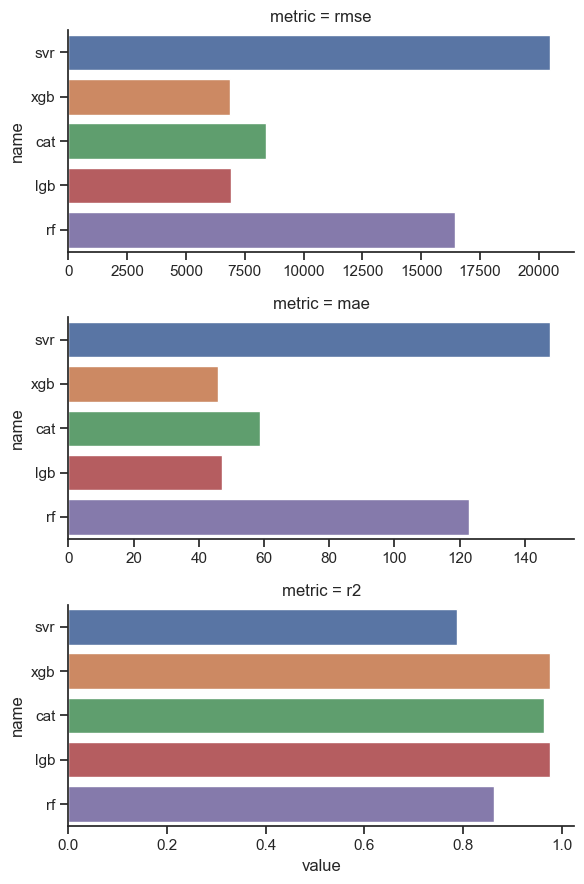

In [26]:
g = sns.FacetGrid(
    model_metrics, row="metric", sharex=False, height=3, aspect=2, hue="name"
)
g.map(sns.barplot, "value", "name", order=model_metrics["name"].unique())

<Axes: xlabel='y_test', ylabel='y_pred'>

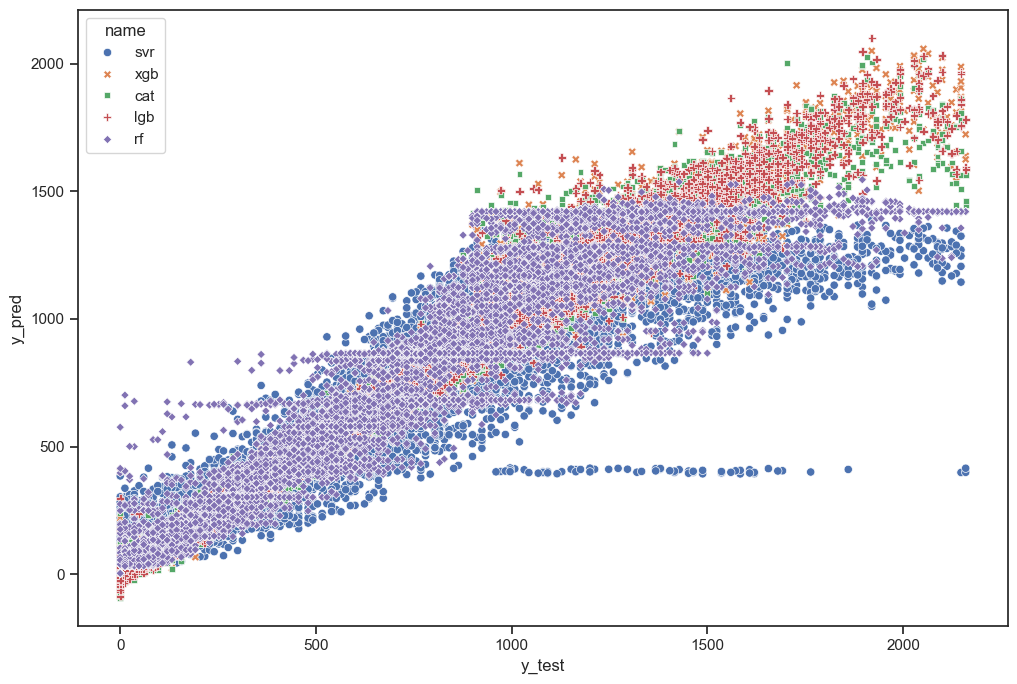

In [27]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=model_preds,
    x="y_test",
    y="y_pred",
    hue="name",
    style="name",
    ax=ax,
)

## experimentation
Use the experimental `DataFrame` to make some predictions

In [28]:
import glob

In [ ]:
# Glob xgb cv file and load the model, since the time is unknown
xgb_choices = glob.glob("xgb_*", root_dir=MODEL_DIR)
best_xgb = jl.load(os.path.join(MODEL_DIR, xgb_choices[-1]))

# Glob cat cv file and load the model, since the time is unknown
cat_choices = glob.glob("cat_*", root_dir=MODEL_DIR)
best_cat = jl.load(os.path.join(MODEL_DIR, cat_choices[-1]))

# Scale the experimental data using the same scaler as before
df_experimental = df_experimental.drop(
    columns=["timestamp", "lift_model", "maintenance_done", "RUL_hrs"]
)
# df_experimental
df_experimental = scaler.transform(df_experimental)

We can also look into the feature importances of each feature we trained the models on.

In [ ]:
feature_importances = {
    "model": [],
    "feature": [],
    "importance_mean": [],
    "importance_std": [],
}

r = permutation_importance(
    best_xgb, X_test, y_test, n_repeats=10, random_state=67, n_jobs=-1
)
for i in r.importances_mean.argsort()[::-1]:
    if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
        feature_importances["model"].append("xgb")
        feature_importances["feature"].append(X.columns[i])
        feature_importances["importance_mean"].append(r.importances_mean[i])
        feature_importances["importance_std"].append(r.importances_std[i])

s = permutation_importance(
    best_cat, X_test, y_test, n_repeats=10, random_state=67, n_jobs=-1
)
for i in s.importances_mean.argsort()[::-1]:
    if s.importances_mean[i] - 2 * s.importances_std[i] > 0:
        feature_importances["model"].append("cat")
        feature_importances["feature"].append(X.columns[i])
        feature_importances["importance_mean"].append(s.importances_mean[i])
        feature_importances["importance_std"].append(s.importances_std[i])

feature_importances = pd.DataFrame(feature_importances)

               DOOR_DIST_mm    1.048 +/- 0.010
             BEARING_TEMP_C    0.630 +/- 0.008
       age_since_last_maint    0.375 +/- 0.003
             lift_age_hours    0.149 +/- 0.002
cumulative_rope_degradation    0.132 +/- 0.003
                ARM_DIST_mm    0.091 +/- 0.001
    cumulative_bearing_heat    0.047 +/- 0.001
                temp_x_rope    0.015 +/- 0.000
           floor_door_ratio    0.015 +/- 0.000
             arm_door_ratio    0.014 +/- 0.001
        DOOR_DIST_mm_per_hr    0.007 +/- 0.000
              FLOOR_DIST_mm    0.006 +/- 0.000
      BEARING_TEMP_C_per_hr    0.004 +/- 0.000
                    lift_id    0.003 +/- 0.000
                ROPE_MFL_mV    0.002 +/- 0.000
         ARM_DIST_mm_per_hr    0.001 +/- 0.000


Text(0.5, 1.0, 'Feature importances')

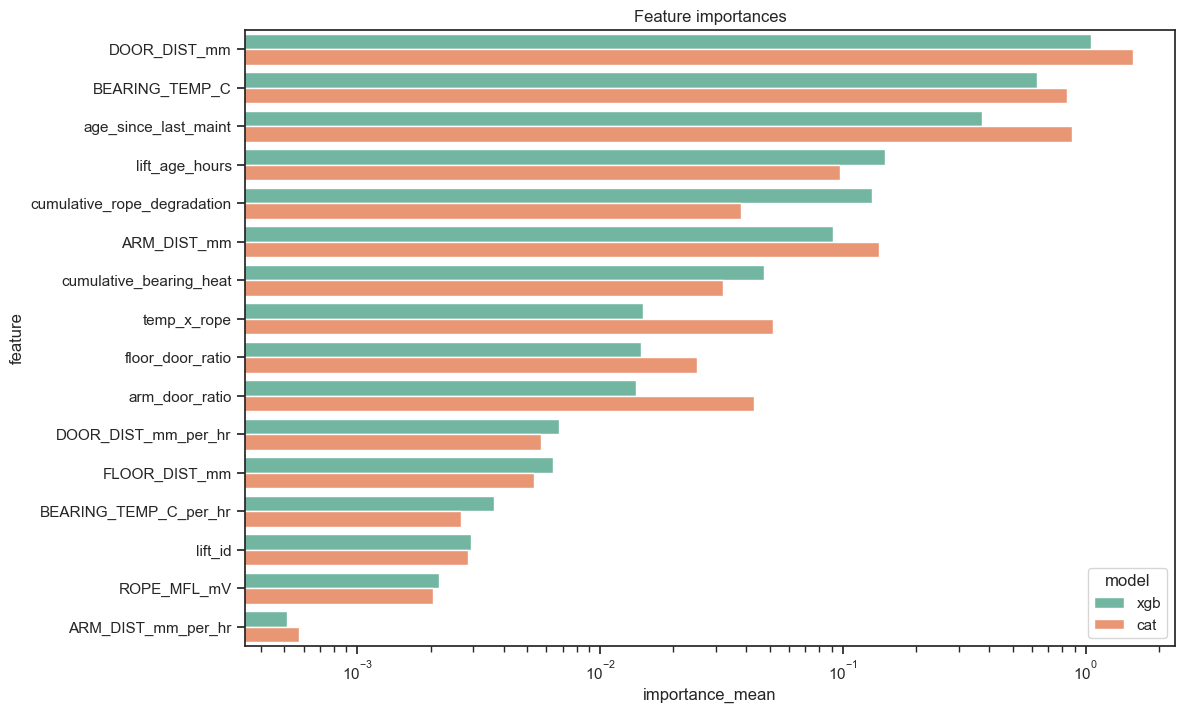

In [45]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.semilogx()
sns.barplot(
    data=feature_importances,
    x="importance_mean",
    y="feature",
    hue="model",
    orient="h",
    palette="Set2",
).set_title("Feature importances")

In [30]:
trial = df_experimental[0].reshape(1, -1)
xgb_preds = best_xgb.predict(trial)
cat_preds = best_cat.predict(trial)
scaler.inverse_transform(trial), xgb_preds, cat_preds

(array([[ 1.00000000e+00,  2.53188000e+05,  4.76000000e-01,
          1.89000000e+00,  4.10000000e-02,  9.78000000e+00,
          3.61140000e+01,  1.72413793e-02,  2.51851719e-01,
          2.16931102e-02,  3.53194920e+02,  2.67840474e+05,
          1.01103006e+06, -4.92000000e-02, -5.16300000e-01,
         -4.57700000e-01, -7.39600000e-01, -2.57630000e+00]]),
 array([1575.8232], dtype=float32),
 array([1622.24968964]))